In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

from scipy.stats import linregress

In [2]:
fund = pd.read_csv("../data/raw/01_fund_master.csv")
nav = pd.read_csv("../data/raw/02_nav_history.csv")
performance = pd.read_csv("../data/raw/07_scheme_performance.csv")
benchmark = pd.read_csv("../data/raw/10_benchmark_indices.csv")

nav["date"] = pd.to_datetime(nav["date"])
benchmark["date"] = pd.to_datetime(benchmark["date"])

In [3]:
nav = nav.sort_values(["amfi_code", "date"])

nav["daily_return"] = (
    nav.groupby("amfi_code")["nav"]
       .pct_change()
)

nav.head()

,amfi_code,date,nav,daily_return
5750,100016,2022-01-03,520.4608,NaN
5751,100016,2022-01-04,515.0971,-0.010306
5752,100016,2022-01-05,521.7239,0.012865
5753,100016,2022-01-06,515.7880,-0.011377
5754,100016,2022-01-07,515.1639,-0.001210


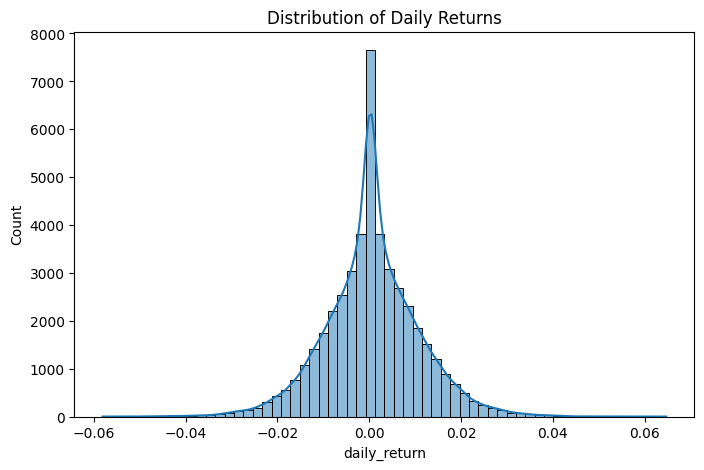

In [4]:
plt.figure(figsize=(8,5))

sns.histplot(
    nav["daily_return"].dropna(),
    bins=60,
    kde=True
)

plt.title("Distribution of Daily Returns")
plt.show()

In [5]:
def calculate_cagr(start_nav, end_nav, years):
    return (end_nav/start_nav)**(1/years)-1

In [6]:
cagr_list=[]

for code, df in nav.groupby("amfi_code"):

    df=df.sort_values("date")

    start=df.iloc[0]["nav"]
    end=df.iloc[-1]["nav"]

    years=(df["date"].max()-df["date"].min()).days/365

    cagr=calculate_cagr(start,end,years)

    cagr_list.append([code,cagr])

cagr_df=pd.DataFrame(
    cagr_list,
    columns=["amfi_code","CAGR"]
)

cagr_df.head()

,amfi_code,CAGR
0,100016,0.026352
1,100025,0.044551
2,100033,0.300997
3,101206,0.235205
4,101207,0.079331


In [7]:
rf=0.065

In [8]:
sharpe=[]

for code,df in nav.groupby("amfi_code"):

    r=df["daily_return"].dropna()

    mean=r.mean()*252

    std=r.std()*np.sqrt(252)

    sharpe_ratio=(mean-rf)/std

    sharpe.append([code,sharpe_ratio])

sharpe_df=pd.DataFrame(
    sharpe,
    columns=["amfi_code","Sharpe"]
)

sharpe_df

,amfi_code,Sharpe
0,100016,-0.201517
1,100025,-0.567095
2,100033,1.093699
3,101206,1.027213
4,101207,0.162661
5,101208,-0.815567
6,102885,0.817099
7,102886,-0.205832
8,102887,0.619518
9,118632,1.081659


In [9]:
sortino=[]

for code,df in nav.groupby("amfi_code"):

    r=df["daily_return"].dropna()

    downside=r[r<0]

    downside_std=downside.std()*np.sqrt(252)

    annual_return=r.mean()*252

    ratio=(annual_return-rf)/downside_std

    sortino.append([code,ratio])

sortino_df=pd.DataFrame(
    sortino,
    columns=["amfi_code","Sortino"]
)

In [10]:
sortino=[]

for code,df in nav.groupby("amfi_code"):

    r=df["daily_return"].dropna()

    downside=r[r<0]

    downside_std=downside.std()*np.sqrt(252)

    annual_return=r.mean()*252

    ratio=(annual_return-rf)/downside_std

    sortino.append([code,ratio])

sortino_df=pd.DataFrame(
    sortino,
    columns=["amfi_code","Sortino"]
)

sortino_df.head()

,amfi_code,Sortino
0,100016,-0.351047
1,100025,-0.941821
2,100033,1.829134
3,101206,1.799563
4,101207,0.276644


In [11]:
benchmark = benchmark.sort_values("date")

nifty = benchmark[
    benchmark["index_name"]=="Nifty 100"
].copy()

nifty["benchmark_return"] = nifty["close_value"].pct_change()

In [13]:
from scipy.stats import linregress

print("Available Benchmarks:")
print(benchmark["index_name"].unique())

# Automatically find Nifty 100
nifty100_name = None
for name in benchmark["index_name"].unique():
    if "100" in str(name):
        nifty100_name = name
        break

print("Using Benchmark:", nifty100_name)

nifty = benchmark[benchmark["index_name"] == nifty100_name].copy()

nifty = nifty.sort_values("date")
nifty["benchmark_return"] = nifty["close_value"].pct_change()

alpha_beta = []

for code, df in nav.groupby("amfi_code"):

    df = df.sort_values("date")

    temp = pd.merge(
        df,
        nifty[["date", "benchmark_return"]],
        on="date",
        how="inner"
    )

    temp = temp.dropna()

    if len(temp) > 30:

        slope, intercept, r_value, p_value, std_err = linregress(
            temp["benchmark_return"],
            temp["daily_return"]
        )

        alpha = intercept * 252
        beta = slope

        alpha_beta.append([code, alpha, beta])

alpha_beta_df = pd.DataFrame(
    alpha_beta,
    columns=["amfi_code", "Alpha", "Beta"]
)

alpha_beta_df.head()

Available Benchmarks:
['NIFTY50' 'CRISIL_LIQUID' 'NIFTY_MIDCAP150' 'CRISIL_GILT' 'NIFTY100'
 'NIFTY500' 'BSE_SMALLCAP']
Using Benchmark: NIFTY100


,amfi_code,Alpha,Beta
0,100016,0.037476,-0.058268
1,100025,0.042818,0.001158
2,100033,0.271954,0.005104
3,101206,0.213998,0.021086
4,101207,0.108971,-0.065289


In [15]:
drawdowns = []

for code, df in nav.groupby("amfi_code"):

    df = df.sort_values("date")

    running_max = df["nav"].cummax()

    drawdown = df["nav"] / running_max - 1

    drawdowns.append([
        code,
        drawdown.min()
    ])

drawdown_df = pd.DataFrame(
    drawdowns,
    columns=["amfi_code", "Max_Drawdown"]
)

drawdown_df.head()

,amfi_code,Max_Drawdown
0,100016,-0.247344
1,100025,-0.043083
2,100033,-0.162172
3,101206,-0.112916
4,101207,-0.354469


In [16]:
print("CAGR:", cagr_df.shape)
print("Sharpe:", sharpe_df.shape)
print("Sortino:", sortino_df.shape)
print("Alpha Beta:", alpha_beta_df.shape)
print("Drawdown:", drawdown_df.shape)

CAGR: (40, 2)
Sharpe: (40, 2)
Sortino: (40, 2)
Alpha Beta: (40, 3)
Drawdown: (40, 2)


In [18]:
scorecard = (
    cagr_df
    .merge(sharpe_df, on="amfi_code")
    .merge(sortino_df, on="amfi_code")
    .merge(alpha_beta_df, on="amfi_code")
    .merge(drawdown_df, on="amfi_code")
)

scorecard = scorecard.merge(
    performance[
        [
            "amfi_code",
            "expense_ratio_pct",
            "return_3yr_pct"
        ]
    ],
    on="amfi_code"
)

scorecard["Score"] = (
    scorecard["return_3yr_pct"].rank(pct=True) * 30 +
    scorecard["Sharpe"].rank(pct=True) * 25 +
    scorecard["Alpha"].rank(pct=True) * 20 +
    (1 - scorecard["expense_ratio_pct"].rank(pct=True)) * 15 +
    (1 - scorecard["Max_Drawdown"].rank(pct=True)) * 10
)

scorecard = scorecard.sort_values(
    "Score",
    ascending=False
)

scorecard.head()

,amfi_code,CAGR,Sharpe,Sortino,Alpha,Beta,Max_Drawdown,expense_ratio_pct,return_3yr_pct,Score
21,119598,0.323981,0.945308,1.675317,0.303370,-0.023196,-0.287060,1.43,23.39,82.7500
25,120505,0.328016,1.180101,2.029353,0.292636,0.000549,-0.181885,1.36,18.08,81.6250
39,149324,0.322621,0.949796,1.619793,0.300579,0.011455,-0.311719,1.52,20.08,77.3125
2,100033,0.300997,1.093699,1.829134,0.271954,0.005104,-0.162172,1.38,16.58,75.3750
30,120843,0.308833,1.306744,2.364320,0.273305,-0.022830,-0.129740,1.45,15.65,74.6250


In [19]:
print(scorecard.shape)

(40, 10)


In [20]:
tracking_error = []

for code, df in nav.groupby("amfi_code"):

    temp = pd.merge(
        df,
        nifty[["date", "benchmark_return"]],
        on="date",
        how="inner"
    ).dropna()

    if len(temp) > 30:

        te = (
            (temp["daily_return"] -
             temp["benchmark_return"]).std()
            * np.sqrt(252)
        )

        tracking_error.append(
            [code, te]
        )

tracking_error_df = pd.DataFrame(
    tracking_error,
    columns=[
        "amfi_code",
        "Tracking_Error"
    ]
)

tracking_error_df.head()

,amfi_code,Tracking_Error
0,100016,0.199284
1,100025,0.134535
2,100033,0.228699
3,101206,0.192706
4,101207,0.292117


In [21]:
scorecard = scorecard.merge(
    tracking_error_df,
    on="amfi_code",
    how="left"
)

scorecard.head()

,amfi_code,CAGR,Sharpe,Sortino,Alpha,Beta,Max_Drawdown,expense_ratio_pct,return_3yr_pct,Score,Tracking_Error
0,119598,0.323981,0.945308,1.675317,0.303370,-0.023196,-0.287060,1.43,23.39,82.7500,0.283881
1,120505,0.328016,1.180101,2.029353,0.292636,0.000549,-0.181885,1.36,18.08,81.6250,0.231968
2,149324,0.322621,0.949796,1.619793,0.300579,0.011455,-0.311719,1.52,20.08,77.3125,0.279170
3,100033,0.300997,1.093699,1.829134,0.271954,0.005104,-0.162172,1.38,16.58,75.3750,0.228699
4,120843,0.308833,1.306744,2.364320,0.273305,-0.022830,-0.129740,1.45,15.65,74.6250,0.206425


In [22]:
scorecard.to_csv(
    "../reports/fund_scorecard.csv",
    index=False
)

alpha_beta_df.to_csv(
    "../reports/alpha_beta.csv",
    index=False
)

tracking_error_df.to_csv(
    "../reports/tracking_error.csv",
    index=False
)

print("All CSV files exported successfully!")

All CSV files exported successfully!


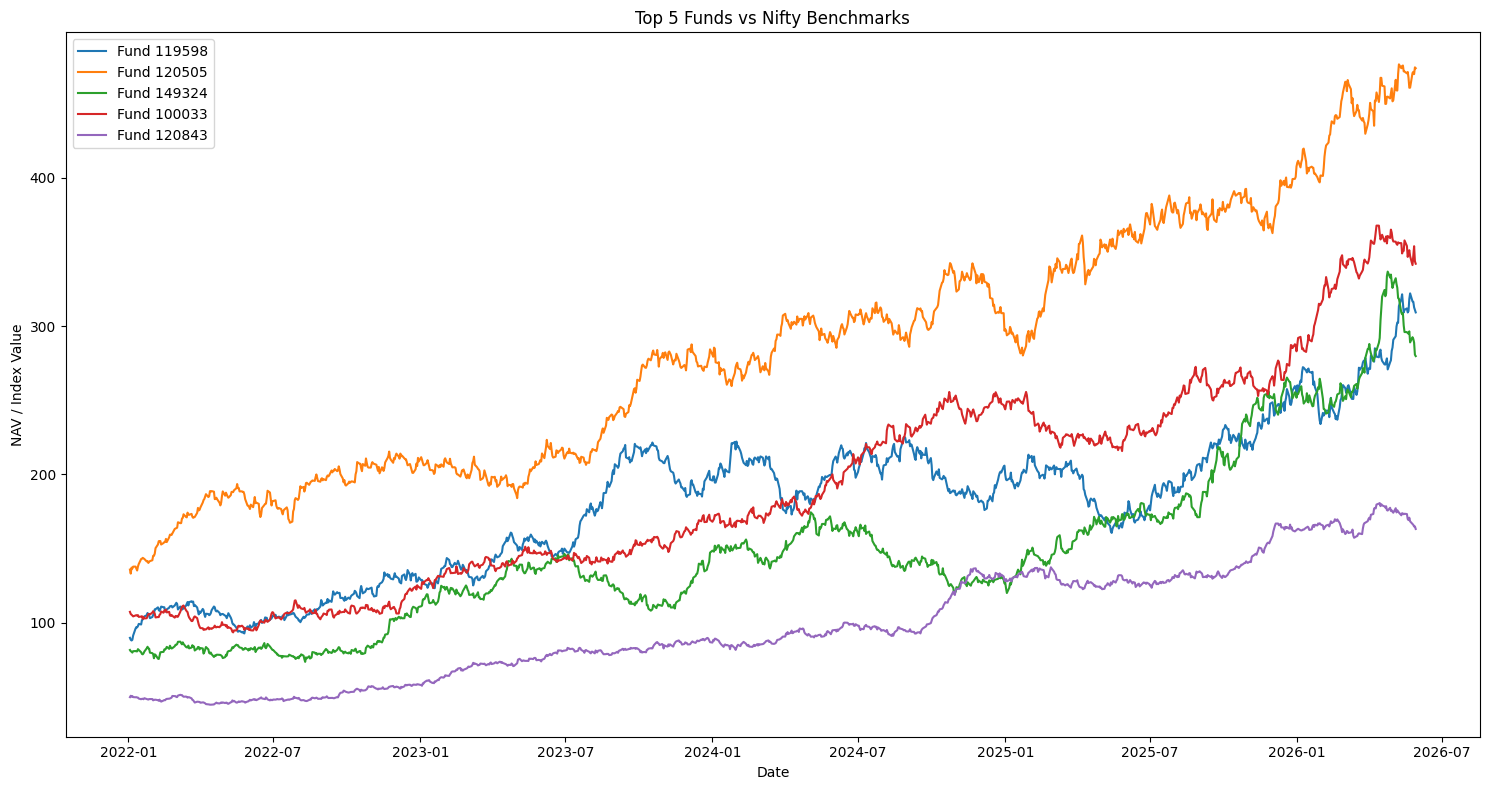

In [23]:
top5 = scorecard.nlargest(5, "Score")["amfi_code"]

plt.figure(figsize=(15,8))

for code in top5:

    temp = nav[
        nav["amfi_code"] == code
    ]

    plt.plot(
        temp["date"],
        temp["nav"],
        label=f"Fund {code}"
    )

# Plot Nifty 50 and Nifty 100
for idx in benchmark["index_name"].unique():

    if "Nifty" in str(idx):

        temp = benchmark[
            benchmark["index_name"] == idx
        ]

        plt.plot(
            temp["date"],
            temp["close_value"],
            linestyle="--",
            linewidth=2,
            label=idx
        )

plt.title("Top 5 Funds vs Nifty Benchmarks")
plt.xlabel("Date")
plt.ylabel("NAV / Index Value")

plt.legend()

plt.tight_layout()

plt.savefig("../reports/charts/benchmark_comparison.png")

plt.show()

In [24]:
reports/charts/benchmark_comparison.png

NameError: name 'reports' is not defined